In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import os

base_path = "/content/drive/MyDrive/RoadSurfaceProject"

folders = [
    "models",
    "core",
    "gui",
    "utils",
    "data"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [21]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/RoadSurfaceProject/models/road_model.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


In [22]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

IMG_SIZE = 128

def preprocess_image(image):
    img = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)
    return img

In [23]:
from google.colab import files

uploaded = files.upload()

Saving road4.jpg to road4.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: [[0.13259453 0.8429042  0.02450118]]


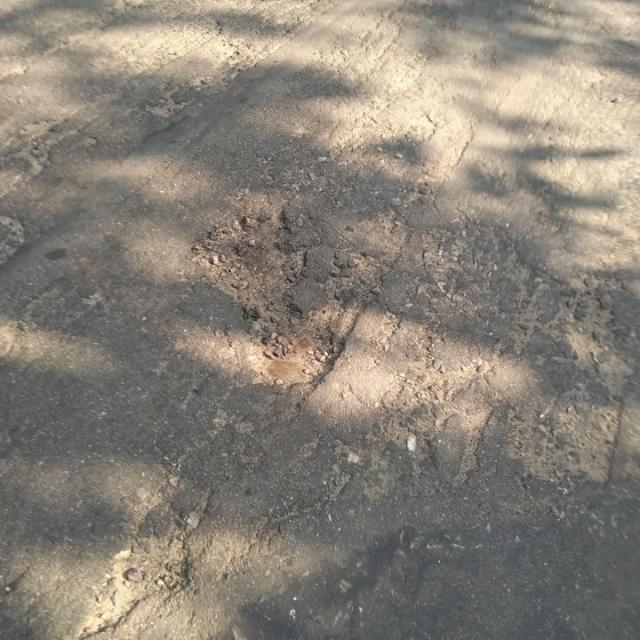

In [24]:
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)

processed = preprocess_image(img)

prediction = model.predict(processed)

print("Prediction:", prediction)

cv2_imshow(img)

In [25]:
class_names = ["damage", "moderate", "smooth"]

def interpret_prediction(prediction):

    index = prediction.argmax()

    label = class_names[index]

    confidence = float(prediction[0][index])

    if label == "smooth":
        rqi = 90
        condition = "GOOD ROAD"
        color = "GREEN"

    elif label == "moderate":
        rqi = 60
        condition = "MODERATE ROAD"
        color = "YELLOW"

    else:
        rqi = 30
        condition = "POOR ROAD"
        color = "RED"

    return label, confidence, rqi, condition, color

In [26]:
import numpy as np

class_names = ['damage','moderate','smooth']

probs = prediction[0]

for i, name in enumerate(class_names):
    print(f"{name}: {probs[i]*100:.2f}%")

damage: 13.26%
moderate: 84.29%
smooth: 2.45%


In [27]:
label, confidence, rqi, condition, color = interpret_prediction(prediction)

print("Road Type:", label)
print("Confidence:", round(confidence*100,2),"%")
print("Road Condition:", condition)
print("Road Quality Index:", rqi)

Road Type: moderate
Confidence: 84.29 %
Road Condition: MODERATE ROAD
Road Quality Index: 60


In [28]:
!pip install gradio opencv-python

In [31]:
%%writefile app.py

import gradio as gr
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("/content/drive/MyDrive/RoadSurfaceProject/models/road_model.keras")

class_names = ['damage','moderate','smooth']


def preprocess_image(img):
    img = cv2.resize(img,(128,128))
    img = img/255.0
    img = np.expand_dims(img,axis=0)
    return img


def interpret_prediction(prediction):

    probs = prediction[0]
    pred_index = np.argmax(probs)

    label = class_names[pred_index]
    confidence = probs[pred_index]

    if label == "smooth":
        condition = "GOOD ROAD"
        rqi = 90
        color = "🟢"

    elif label == "moderate":
        condition = "MODERATE ROAD"
        rqi = 60
        color = "🟡"

    else:
        condition = "POOR ROAD"
        rqi = 30
        color = "🔴"

    result = f"""
### Road Type: {label}

Confidence: {confidence*100:.2f} %

Road Condition: {condition}

Road Quality Index (RQI): {rqi}
"""

    return result


def predict_image(image):

    img = cv2.cvtColor(image,cv2.COLOR_RGB2BGR)
    processed = preprocess_image(img)

    prediction = model.predict(processed)

    return interpret_prediction(prediction)


def predict_video(video):

    cap = cv2.VideoCapture(video)
    ret, frame = cap.read()

    if not ret:
        return "Could not read video"

    processed = preprocess_image(frame)
    prediction = model.predict(processed)

    return interpret_prediction(prediction)


with gr.Blocks(theme=gr.themes.Soft(primary_hue="blue", neutral_hue="slate")) as app:

    gr.Markdown("# 🚧 Road Surface Condition Detection System")

    with gr.Tab("Image Analysis"):

        img_input = gr.Image(type="numpy")
        img_output = gr.Markdown()

        btn1 = gr.Button("Analyze Road Image")

        btn1.click(predict_image, inputs=img_input, outputs=img_output)

    with gr.Tab("Video Analysis"):

        vid_input = gr.Video()
        vid_output = gr.Markdown()

        btn2 = gr.Button("Analyze Road Video")

        btn2.click(predict_video, inputs=vid_input, outputs=vid_output)


app.launch(share=True)

Overwriting app.py


In [ ]:
!python app.py

2026-03-08 05:16:33.344014: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772946993.397515    8555 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772946993.413789    8555 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772946993.459862    8555 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772946993.459930    8555 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772946993.459935    8555 computation_placer.cc:177] computation placer alr